In [11]:
import sys
!{sys.executable} -m pip install opencv-python mtcnn tqdm pillow matplotlib tensorflow scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from mtcnn import MTCNN
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [13]:
dataset_path = "dataset"
processed_path = "dataset_procesado"

os.makedirs(processed_path, exist_ok=True)

print("clases encontradas:")
print(os.listdir(dataset_path))

Clases encontradas:
['alumno1', 'alumno2', 'alumno3', 'famoso1', 'famoso2', 'famoso3', 'famoso4', 'famoso5', 'famoso6', 'famoso7', 'famoso8']


In [31]:
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(".webp"):
            old_path = os.path.join(root, file)
            new_path = os.path.splitext(old_path)[0] + ".jpg"

            try:
                img = Image.open(old_path).convert("RGB")
                img.save(new_path, "JPEG")
                os.remove(old_path)
                print(f"convertido: {old_path} -> {new_path}")
            except Exception as e:
                print(f"error convirtiendo {old_path}: {e}")



In [15]:
detector = MTCNN()

def extract_face(image_path, required_size=(160, 160)):
    image = cv2.imread(image_path)
    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(image_rgb)

    if len(results) == 0:
        return None

    best_face = max(results, key=lambda x: x["confidence"])
    x, y, w, h = best_face["box"]

    x, y = abs(x), abs(y)
    face = image_rgb[y:y+h, x:x+w]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)
    return face

In [16]:
classes = sorted(os.listdir(dataset_path))

resumen = []

for class_name in classes:
    class_folder = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    save_folder = os.path.join(processed_path, class_name)
    os.makedirs(save_folder, exist_ok=True)

    images = os.listdir(class_folder)
    guardadas = 0
    omitidas = 0

    for img_name in tqdm(images, desc=f"procesando {class_name}"):
        img_path = os.path.join(class_folder, img_name)

        try:
            face = extract_face(img_path)

            if face is not None:
                save_path = os.path.join(save_folder, f"face_{guardadas}.jpg")
                cv2.imwrite(save_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                guardadas += 1
            else:
                omitidas += 1

        except Exception as e:
            print(f"Error con {img_name}: {e}")
            omitidas += 1

    resumen.append((class_name, len(images), guardadas, omitidas))

print("preprocesamiento terminado")
print("\nresumen:")
for r in resumen:
    print(f"{r[0]} -> originales: {r[1]}, procesadas: {r[2]}, omitidas: {r[3]}")

Procesando famoso8: 100%|██████████| 10/10 [00:00<00:00, 13.08it/s]

Preprocesamiento terminado.

Resumen:
alumno1 -> originales: 10, procesadas: 10, omitidas: 0
alumno2 -> originales: 11, procesadas: 10, omitidas: 1
alumno3 -> originales: 10, procesadas: 10, omitidas: 0
famoso1 -> originales: 10, procesadas: 10, omitidas: 0
famoso2 -> originales: 10, procesadas: 10, omitidas: 0
famoso3 -> originales: 10, procesadas: 10, omitidas: 0
famoso4 -> originales: 10, procesadas: 10, omitidas: 0
famoso5 -> originales: 10, procesadas: 10, omitidas: 0
famoso6 -> originales: 10, procesadas: 10, omitidas: 0
famoso7 -> originales: 10, procesadas: 10, omitidas: 0
famoso8 -> originales: 10, procesadas: 10, omitidas: 0


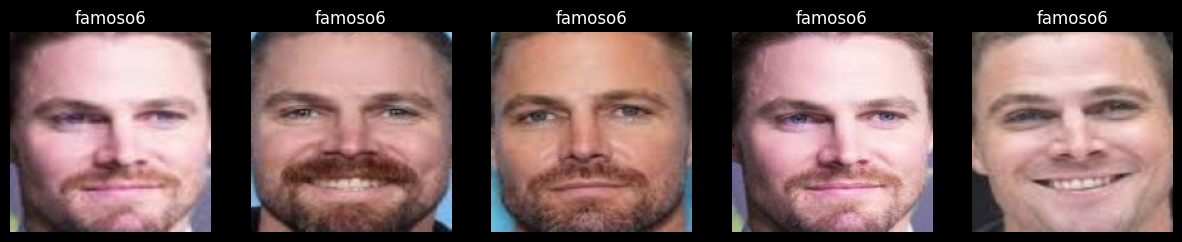

In [17]:
import random

persona = random.choice(os.listdir(processed_path))
ruta = os.path.join(processed_path, persona)
imagenes = os.listdir(ruta)[:5]

plt.figure(figsize=(15,3))

for i, img_name in enumerate(imagenes):
    img = cv2.imread(os.path.join(ruta, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(imagenes), i+1)
    plt.imshow(img)
    plt.title(persona)
    plt.axis("off")

plt.show()

In [18]:
img_height = 160
img_width = 160
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_data = datagen.flow_from_directory(
    processed_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    processed_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 88 images belonging to 11 classes.
Found 22 images belonging to 11 classes.


In [19]:
print(train_data.class_indices)

{'alumno1': 0, 'alumno2': 1, 'alumno3': 2, 'famoso1': 3, 'famoso2': 4, 'famoso3': 5, 'famoso4': 6, 'famoso5': 7, 'famoso6': 8, 'famoso7': 9, 'famoso8': 10}


In [20]:
num_classes = len(train_data.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(160,160,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\rened\PycharmProjects\DATASETIA\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,403,211 (20.61 MB)

 Trainable params: 5,403,211 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.1250 - loss: 2.3602 - val_accuracy: 0.1364 - val_loss: 2.3747
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.1364 - loss: 2.3881 - val_accuracy: 0.1364 - val_loss: 2.3455
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.1477 - loss: 2.3137 - val_accuracy: 0.1364 - val_loss: 2.3461
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.1477 - loss: 2.3095 - val_accuracy: 0.1364 - val_loss: 2.3395
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.1705 - loss: 2.3201 - val_accuracy: 0.2273 - val_loss: 2.3128
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.1705 - loss: 2.2528 - val_accuracy: 0.1818 - val_loss: 2.3352
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.1932 - loss: 2.2329 - val_accuracy: 0.1818 - val_loss: 2.2559
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.1364 - loss: 2.3364 - val_accuracy: 0.1818 - val_loss:

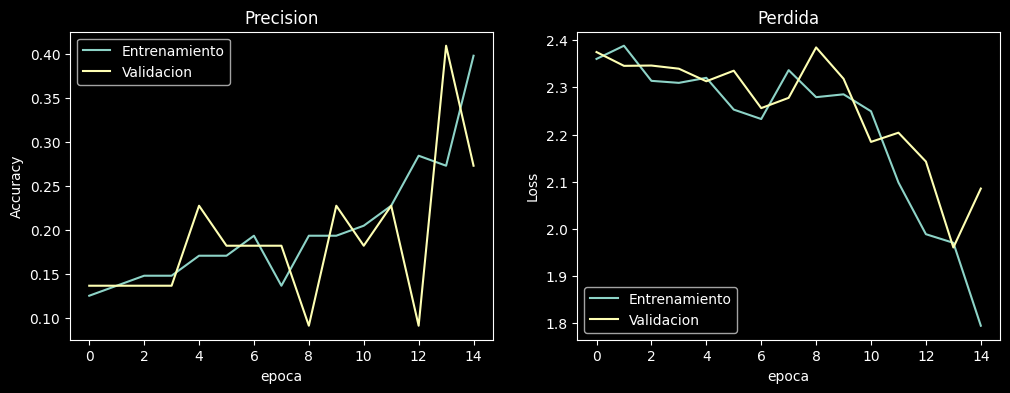

In [32]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validacion')
plt.title('Precision')
plt.xlabel('epoca')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validacion')
plt.title('Perdida')
plt.xlabel('epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [24]:
loss, acc = model.evaluate(val_data)
print(f"Precision final en validacion: {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2273 - loss: 2.0140 
Precisión final en validación: 22.73%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


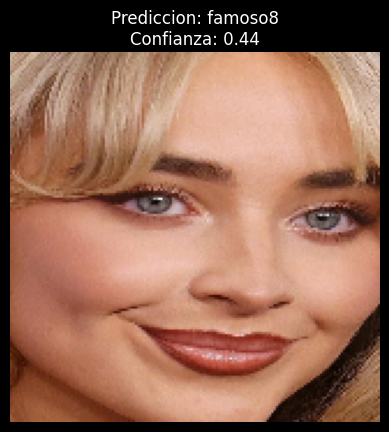

In [33]:
class_names = list(train_data.class_indices.keys())

test_img_path = "prueba.jpg"

face = extract_face(test_img_path, required_size=(160,160))

if face is None:
    print("No se detectó ningun rostro.")
else:
    img_array = face.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.imshow(face)
    plt.title(f"Prediccion: {predicted_class}\nConfianza: {confidence:.2f}")
    plt.axis("off")
    plt.show()

In [34]:
model.save("modelo_reconocimiento_facial.h5")
